In [98]:
import numpy as np
import pandas as pd
import catboost as cb
from catboost import Pool, CatBoostRegressor

import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from matplotlib import pyplot as plt

# Global Methods

In [99]:
# Constants
train_cities = [
    'boston',
    'chicago',
    'columbus',
    'dallas',
    'denver',
    'la',
    'newyork',
    'portland',
    'seattle',
    'sfo',
]

test_cities = [
    'austin',
    'san_diego',
    'newark',
]

city_pairs = [
    {'train': 'dallas', 'test': 'austin'},
    {'train': 'la', 'test': 'san_diego'},
    {'train': 'newyork', 'test': 'newark'},
]

storage = []

In [100]:
def process_data(city: str):
    """
    Function reads and cleans a dataset for a given city.
    :param city: The name of the city to process.
    :returns: The train data and labels for the dataset.
    """
    # Get data
    data_df = pd.read_csv(f"../Data/data_wrangling/marged_data_13_cities/{city}_merge.csv")

    # Clean data
    data_df = data_df.iloc[:,2:]
    data = data_df.loc[:, (data_df.columns != 'price') & (data_df.columns != 'income')]
    labels = data_df['price']
    return data, labels


def train_model(data: pd.DataFrame, labels: pd.DataFrame):
    """
    Trains a model given data and labels.
    :param data: Input features.
    :param labels: Input labels.
    :returns: A CatBoostRegressor model.
    """
    # Init Pool
    train_pool = Pool(data, 
                      labels, 
                      cat_features=[0,2,5,6])
    
    # Define Model
    model = CatBoostRegressor(loss_function='RMSE', logging_level='Silent')
    
    # Train Model
    grid = {'iterations': [16, 64],
            'learning_rate': [0.03, 0.1],
            'depth': [4, 8, 12]}
    model.grid_search(grid, train_pool, verbose=False, plot=True)
    return model


def assess_model(model: CatBoostRegressor, data: pd.DataFrame, labels: pd.DataFrame, name: str, storage: list):
    """
    Function generates model performance metrics.
    :param model: A trained model.
    :param data: Input features.
    :param labels: Input labels.
    :param name: The name of the model.
    :param storage: Persistent storage for metrics.
    :returns: None.
    """
    # Get prediction metrics
    pred = model.predict(data)
    rmse = (np.sqrt(mean_squared_error(labels, pred)))
    r2 = r2_score(labels, pred)
    print("Testing performance")
    print('RMSE: {:.2f}'.format(rmse))
    print('R2: {:.2f}'.format(r2))
    storage.append({
        'model': name,
        'rmse': rmse,
        'r2': r2
    })
    

def feature_importance(model: CatBoostRegressor, data: pd.DataFrame):
    """
    Function plots feature importances for a given GBT.
    :param model: A trained model.
    :param data: Input features.
    :returns: None.
    """
    sorted_feature_importance = model.feature_importances_.argsort()
    plt.barh(data.columns[sorted_feature_importance], 
            model.feature_importances_[sorted_feature_importance], 
            color='turquoise')
    plt.xlabel("CatBoost Feature Importance")

# Evaluate "Similar City" Models

--------------------------------------------------
Training dallas and testing on austin
--------------------------------------------------


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training metrics:
Testing performance
RMSE: 75.08
R2: 0.77
Test metrics:
Testing performance
RMSE: 453.85
R2: 0.10


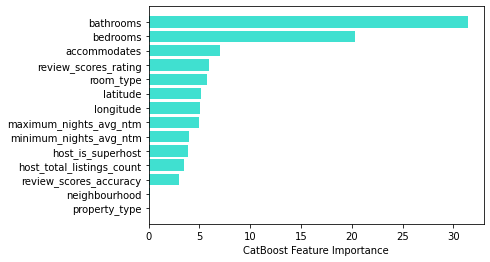

In [101]:
pair = city_pairs[0]
print('-' * 50)
print(f"Training {pair['train']} and testing on {pair['test']}")
print('-' * 50)

train_data, train_labels = process_data(pair['train'])
test_data, test_labels = process_data(pair['test'])
model = train_model(train_data, train_labels)

print("Training metrics:")
assess_model(model, train_data, train_labels, 'Dallas', storage)
print("Test metrics:")
assess_model(model, test_data, test_labels, 'Dallas vs Austin', storage)
feature_importance(model, train_data)

--------------------------------------------------
Training la and testing on san_diego
--------------------------------------------------


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training metrics:
Testing performance
RMSE: 205.92
R2: 0.72
Test metrics:
Testing performance
RMSE: 200.45
R2: 0.47


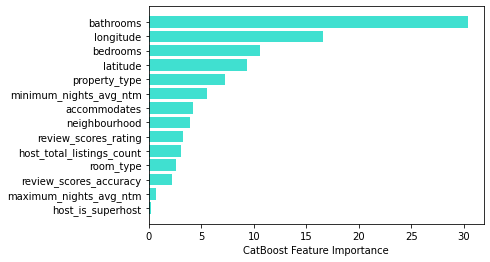

In [102]:
pair = city_pairs[1]
print('-' * 50)
print(f"Training {pair['train']} and testing on {pair['test']}")
print('-' * 50)

train_data, train_labels = process_data(pair['train'])
test_data, test_labels = process_data(pair['test'])
model = train_model(train_data, train_labels)

print("Training metrics:")
assess_model(model, train_data, train_labels, 'Los Angeles', storage)
print("Test metrics:")
assess_model(model, test_data, test_labels, 'Los Angeles vs San Diego', storage)
feature_importance(model, train_data)

--------------------------------------------------
Training newyork and testing on newark
--------------------------------------------------


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training metrics:
Testing performance
RMSE: 204.25
R2: 0.27
Test metrics:
Testing performance
RMSE: 314.92
R2: -0.16


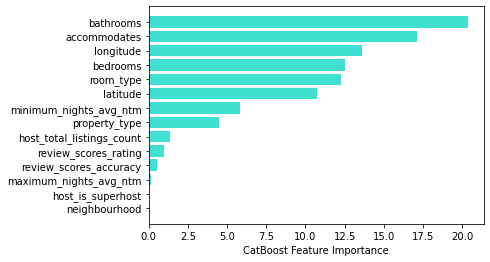

In [103]:
pair = city_pairs[2]
print('-' * 50)
print(f"Training {pair['train']} and testing on {pair['test']}")
print('-' * 50)

train_data, train_labels = process_data(pair['train'])
test_data, test_labels = process_data(pair['test'])
model = train_model(train_data, train_labels)

print("Training metrics:")
assess_model(model, train_data, train_labels, 'New York', storage)
print("Test metrics:")
assess_model(model, test_data, test_labels, 'New York vs Newark', storage)
feature_importance(model, train_data)

# Evaluate "Global" Model

In [104]:
# Generate "Global" training set
global_data = None
global_labels = None

for city in train_cities:
    train_data, train_labels = process_data(city)
    
    if global_data is None:
        global_data = train_data
        global_labels = train_labels
    else:
        global_data = pd.concat([global_data, train_data], ignore_index=True)
        global_labels = pd.concat([global_labels, train_labels], ignore_index=True)

In [105]:
global_model = train_model(global_data, global_labels)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training metrics:
Testing performance
RMSE: 195.89
R2: 0.53
Test metrics:
Testing performance
RMSE: 426.20
R2: 0.20


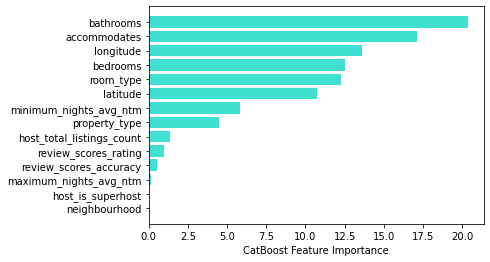

In [106]:
test_data, test_labels = process_data(test_cities[0])

print("Training metrics:")
assess_model(global_model, global_data, global_labels, 'Global', storage)
print("Test metrics:")
assess_model(model, test_data, test_labels, 'Global vs Austin', storage)
feature_importance(model, train_data)

Training metrics:
Testing performance
RMSE: 195.89
R2: 0.53
Test metrics:
Testing performance
RMSE: 196.44
R2: 0.49


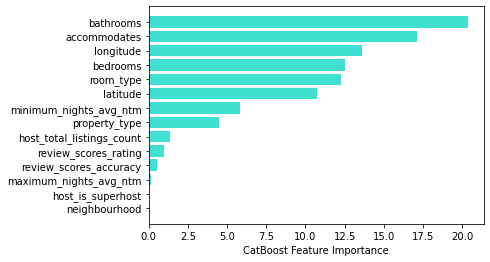

In [107]:
test_data, test_labels = process_data(test_cities[1])

print("Training metrics:")
assess_model(global_model, global_data, global_labels, 'Global', [])
print("Test metrics:")
assess_model(model, test_data, test_labels, 'Global vs San Diego', storage)
feature_importance(model, train_data)

Training metrics:
Testing performance
RMSE: 195.89
R2: 0.53
Test metrics:
Testing performance
RMSE: 314.92
R2: -0.16


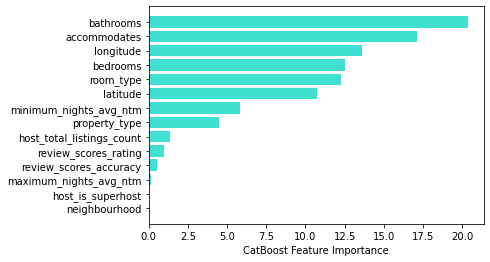

In [108]:
test_data, test_labels = process_data(test_cities[2])

print("Training metrics:")
assess_model(global_model, global_data, global_labels, 'Global', [])
print("Test metrics:")
assess_model(model, test_data, test_labels, 'Global vs Newark', storage)
feature_importance(model, train_data)

# Display final output table

In [113]:
metrics_df = pd.DataFrame.from_records(storage)

In [125]:
# Training Metrics
metrics_df.iloc[[0, 2, 4, 6],:].head(50)

,model,rmse,r2
0,Dallas,75.081864,0.767992
2,Los Angeles,205.921269,0.716196
4,New York,204.245133,0.270105
6,Global,195.893835,0.528817


In [126]:
# Test Metrics
metrics_df.iloc[[1, 3, 5, 7, 8, 9],:].head(50)

,model,rmse,r2
1,Dallas vs Austin,453.852147,0.098030
3,Los Angeles vs San Diego,200.445448,0.470456
5,New York vs Newark,314.922904,-0.159525
7,Global vs Austin,426.197506,0.204601
8,Global vs San Diego,196.443860,0.491388
9,Global vs Newark,314.922904,-0.159525
